In [1]:
import numpy as np

In [3]:
help(np.newaxis)

Help on NoneType object:

class NoneType(object)
 |  Methods defined here:
 |  
 |  __bool__(self, /)
 |      True if self else False
 |  
 |  __repr__(self, /)
 |      Return repr(self).
 |  
 |  ----------------------------------------------------------------------
 |  Static methods defined here:
 |  
 |  __new__(*args, **kwargs) from builtins.type
 |      Create and return a new object.  See help(type) for accurate signature.



In [1]:
from KNN import KNN
import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

In [2]:
df = pd.read_csv('base3.csv')

In [3]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [4]:
df.shape

(400, 5)

In [5]:
#Suppresion de la colonne User ID car elle n'apporte naturellement aucune information.
df.drop('User ID', axis=1,inplace=True)

In [6]:
#Encodage de la variable catégorielle Gender

le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

In [7]:
# Préparation de X et de y.

X = df.drop(['Purchased'],axis=1)
y = df['Purchased']

In [8]:
X.ndim

2

In [9]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [10]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
model = KNN(k=7,distance_metric ="manhattan",task = "Classification")

In [12]:
model.fit(X_train,y_train.values)

In [13]:
predictions = model.predict(X_test)

Début des prédictions
Calcul des distances...
Calcul des distances...
Calcul des distances...
Calcul des distances...
Calcul des distances...
Calcul des distances...
Calcul des distances...
Calcul des distances...
Calcul des distances...
Calcul des distances...
Calcul des distances...
Calcul des distances...
Calcul des distances...
Calcul des distances...
Calcul des distances...
Calcul des distances...
Calcul des distances...
Calcul des distances...
Calcul des distances...
Calcul des distances...
Calcul des distances...
Calcul des distances...
Calcul des distances...
Calcul des distances...
Calcul des distances...
Calcul des distances...
Calcul des distances...
Calcul des distances...
Calcul des distances...
Calcul des distances...
Calcul des distances...
Calcul des distances...
Calcul des distances...
Calcul des distances...
Calcul des distances...
Calcul des distances...
Calcul des distances...
Calcul des distances...
Calcul des distances...
Calcul des distances...
Calcul des distanc

In [14]:
print(predictions)

[np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1)

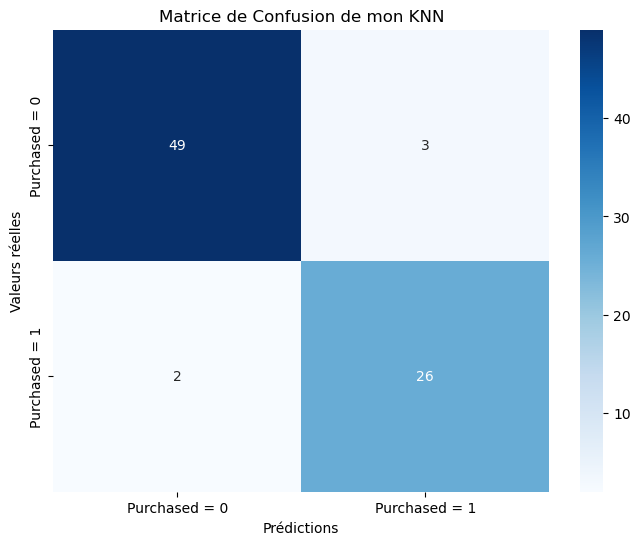

              precision    recall  f1-score   support

           0       0.96      0.94      0.95        52
           1       0.90      0.93      0.91        28

    accuracy                           0.94        80
   macro avg       0.93      0.94      0.93        80
weighted avg       0.94      0.94      0.94        80



In [15]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Générer la matrice (comparaison entre les vraies étiquettes et tes prédictions)
cm = confusion_matrix(y_test, predictions)

# 2. L'afficher de manière visuelle avec Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Purchased = 0', 'Purchased = 1'], 
            yticklabels=['Purchased = 0', 'Purchased = 1'])

plt.xlabel('Prédictions')
plt.ylabel('Valeurs réelles')
plt.title('Matrice de Confusion de mon KNN')
plt.show()

# 3. Afficher les statistiques détaillées
print(classification_report(y_test, predictions))

**Utilisation de KNeighborsClassifier pour une comparaison de performances**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

model2 = KNeighborsClassifier(n_neighbors=7)


In [17]:
model2.fit(X_train,y_train)

,n_neighbors,7
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [18]:
predictions2 = model2.predict(X_test)

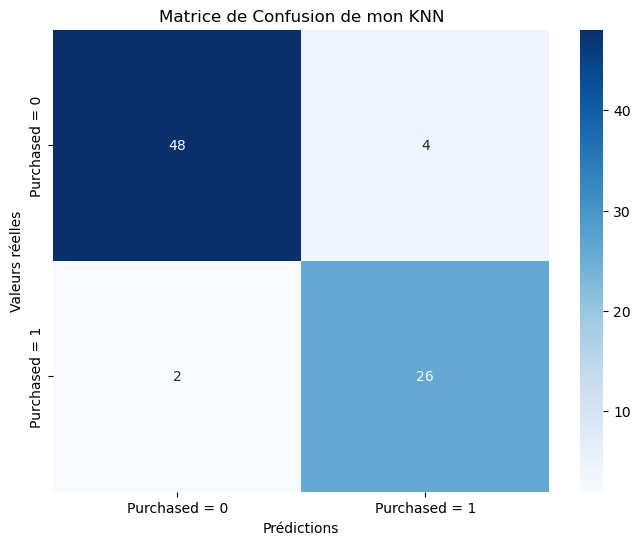

              precision    recall  f1-score   support

           0       0.96      0.92      0.94        52
           1       0.87      0.93      0.90        28

    accuracy                           0.93        80
   macro avg       0.91      0.93      0.92        80
weighted avg       0.93      0.93      0.93        80



In [19]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Générer la matrice (comparaison entre les vraies étiquettes et tes prédictions)
cm = confusion_matrix(y_test, predictions2)

# 2. L'afficher de manière visuelle avec Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Purchased = 0', 'Purchased = 1'], 
            yticklabels=['Purchased = 0', 'Purchased = 1'])

plt.xlabel('Prédictions')
plt.ylabel('Valeurs réelles')
plt.title('Matrice de Confusion de mon KNN')
plt.show()

# 3. Afficher les statistiques détaillées
print(classification_report(y_test, predictions2))